# Installation des dépendances

In [ ]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn joblib mlflow

# Importation des bibliothèques

In [1]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("Environnement initialisé.")


/Users/julien/Desktop/Ynov/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environnement initialisé.


# Présentation du problème

In [2]:
PROJECT_NAME = "eligibilite-livraison-express"
MODEL_VERSION = "1.0.0"

print(f"Projet : {PROJECT_NAME}")
print(f"Version du modèle : {MODEL_VERSION}")


Projet : eligibilite-livraison-express
Version du modèle : 1.0.0


**Objectif métier :**

Prédire si une commande peut bénéficier d’une livraison express.

La variable cible est :

`1` ou `True` : commande éligible ;
`0` ou `False` : commande non éligible.
Le modèle ne doit pas remplacer les règles métier. Il fournit une aide à la décision à partir de caractéristiques liées à la commande, au stock, à la préparation et à la logistique.

# Génération d’un jeu de données fictif

In [3]:
def generate_orders_dataset(n_rows=6000, random_state=42):
    """
    Génère un jeu de données fictif représentant des commandes.
    Le jeu de données est volontairement synthétique afin que le notebook
    soit exécutable sans source externe.
    """
    rng = np.random.default_rng(random_state)

    order_date = pd.date_range(
        start="2025-01-01",
        end="2025-12-31",
        periods=n_rows
    )

    hour = rng.integers(7, 23, size=n_rows)
    day_of_week = pd.Series(order_date).dt.dayofweek.to_numpy()
    weekend = (day_of_week >= 5).astype(int)

    data = pd.DataFrame({
        "order_id": [f"CMD-{i:06d}" for i in range(1, n_rows + 1)],
        "order_date": order_date,
        "hour": hour,
        "day_of_week": day_of_week,
        "weekend": weekend,
        "distance_km": np.round(rng.gamma(shape=2.0, scale=4.0, size=n_rows), 2),
        "order_value_eur": np.round(rng.uniform(10, 250, size=n_rows), 2),
        "weight_kg": np.round(rng.uniform(0.2, 25, size=n_rows), 2),
        "stock_available": rng.binomial(1, 0.85, size=n_rows),
        "preparation_time_min": np.round(
            rng.normal(loc=25, scale=10, size=n_rows).clip(5, 90),
            1
        ),
        "carrier_capacity": np.round(
            rng.uniform(0.2, 1.0, size=n_rows),
            2
        ),
        "weather": rng.choice(
            ["normal", "pluie", "neige", "orage"],
            size=n_rows,
            p=[0.65, 0.20, 0.10, 0.05]
        ),
        "delivery_zone": rng.choice(
            ["centre", "proche_banlieue", "banlieue", "rurale"],
            size=n_rows,
            p=[0.30, 0.30, 0.25, 0.15]
        ),
        "customer_type": rng.choice(
            ["standard", "premium"],
            size=n_rows,
            p=[0.80, 0.20]
        ),
    })

    # Coefficient de difficulté lié à la zone de livraison
    zone_penalty = data["delivery_zone"].map({
        "centre": 0,
        "proche_banlieue": 0.10,
        "banlieue": 0.25,
        "rurale": 0.45,
    })

    weather_penalty = data["weather"].map({
        "normal": 0,
        "pluie": 0.10,
        "neige": 0.25,
        "orage": 0.30,
    })

    customer_bonus = (data["customer_type"] == "premium").astype(int) * 0.15

    # Score latent simulant une décision métier
    score = (
        2.5
        - 0.18 * data["distance_km"]
        - 0.035 * data["preparation_time_min"]
        - 0.035 * data["weight_kg"]
        - zone_penalty
        - weather_penalty
        + 1.8 * data["stock_available"]
        + 1.3 * data["carrier_capacity"]
        + customer_bonus
        - 0.40 * data["weekend"]
        - 0.08 * np.maximum(data["hour"] - 18, 0)
    )

    probability = 1 / (1 + np.exp(-score))

    data["express_eligible"] = rng.binomial(1, probability)

    return data


orders = generate_orders_dataset()

orders.head()


,order_id,order_date,hour,day_of_week,weekend,distance_km,order_value_eur,weight_kg,stock_available,preparation_time_min,carrier_capacity,weather,delivery_zone,customer_type,express_eligible
0,CMD-000001,2025-01-01 00:00:00.000000000,8,2,0,13.75,89.21,16.11,1,43.6,0.98,normal,centre,standard,1
1,CMD-000002,2025-01-01 01:27:22.473745624,19,2,0,17.03,238.79,24.70,1,5.0,0.52,normal,centre,premium,0
2,CMD-000003,2025-01-01 02:54:44.947491248,17,2,0,3.49,18.75,4.03,1,18.4,0.90,normal,rurale,premium,1
3,CMD-000004,2025-01-01 04:22:07.421236872,14,2,0,15.57,94.80,11.41,0,27.6,0.53,normal,rurale,standard,0
4,CMD-000005,2025-01-01 05:49:29.894982497,13,2,0,5.26,218.19,22.66,1,25.0,0.29,pluie,proche_banlieue,standard,1


# Exploration du jeu de données

In [4]:
print(f"Nombre de lignes : {len(orders):,}")
print(f"Nombre de colonnes : {orders.shape[1]}")
print("\nTypes de données :")
display(orders.dtypes)

print("\nRépartition de la variable cible :")
display(
    orders["express_eligible"]
    .value_counts(normalize=True)
    .rename({0: "Non éligible", 1: "Éligible"})
    .mul(100)
    .round(2)
)

Nombre de lignes : 6,000
Nombre de colonnes : 15

Types de données :


order_id                        object
order_date              datetime64[ns]
hour                             int64
day_of_week                      int32
weekend                          int64
distance_km                    float64
order_value_eur                float64
weight_kg                      float64
stock_available                  int64
preparation_time_min           float64
carrier_capacity               float64
weather                         object
delivery_zone                   object
customer_type                   object
express_eligible                 int64
dtype: object


Répartition de la variable cible :


express_eligible
Éligible        78.85
Non éligible    21.15
Name: proportion, dtype: float64

In [5]:
orders.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,6000,6000,CMD-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,6000,NaN,NaN,NaN,2025-07-02 00:00:00.000000256,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-02 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
hour,6000.0,NaN,NaN,NaN,14.475667,7.0,10.0,14.0,19.0,22.0,4.603579
day_of_week,6000.0,NaN,NaN,NaN,2.999833,0.0,1.0,3.0,5.0,6.0,2.000042
weekend,6000.0,NaN,NaN,NaN,0.285667,0.0,0.0,0.0,1.0,1.0,0.451769
distance_km,6000.0,NaN,NaN,NaN,7.998038,0.06,3.92,6.7,10.68,59.29,5.643331
order_value_eur,6000.0,NaN,NaN,NaN,131.663683,10.0,71.065,132.71,192.5475,249.99,70.139832
weight_kg,6000.0,NaN,NaN,NaN,12.599705,0.2,6.4375,12.525,18.9325,25.0,7.139433
stock_available,6000.0,NaN,NaN,NaN,0.850667,0.0,1.0,1.0,1.0,1.0,0.356446
preparation_time_min,6000.0,NaN,NaN,NaN,25.02385,5.0,18.2,24.9,31.6,68.3,9.863775


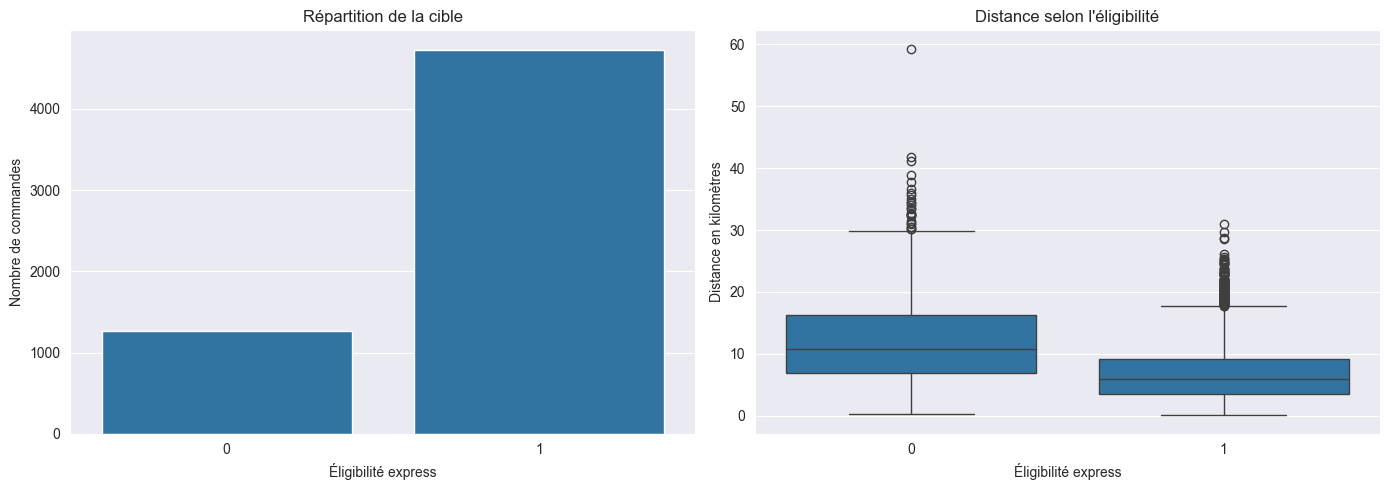

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=orders,
    x="express_eligible",
    ax=axes[0]
)
axes[0].set_title("Répartition de la cible")
axes[0].set_xlabel("Éligibilité express")
axes[0].set_ylabel("Nombre de commandes")

sns.boxplot(
    data=orders,
    x="express_eligible",
    y="distance_km",
    ax=axes[1]
)
axes[1].set_title("Distance selon l'éligibilité")
axes[1].set_xlabel("Éligibilité express")
axes[1].set_ylabel("Distance en kilomètres")

plt.tight_layout()
plt.show()


# Contrôles de qualité des données

In [7]:
def validate_dataset(df):
    """
    Contrôles de qualité élémentaires sur les données d'entrée.
    Cette fonction pourra ensuite être déplacée dans un module data_quality.py.
    """
    required_columns = {
        "order_id",
        "order_date",
        "hour",
        "day_of_week",
        "weekend",
        "distance_km",
        "order_value_eur",
        "weight_kg",
        "stock_available",
        "preparation_time_min",
        "carrier_capacity",
        "weather",
        "delivery_zone",
        "customer_type",
        "express_eligible",
    }

    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"Colonnes obligatoires absentes : {sorted(missing_columns)}"
        )

    if df["order_id"].duplicated().any():
        raise ValueError("Des identifiants de commande sont dupliqués.")

    if df["express_eligible"].isna().any():
        raise ValueError("La variable cible contient des valeurs manquantes.")

    if not df["hour"].between(0, 23).all():
        raise ValueError("Certaines heures sont invalides.")

    if not df["distance_km"].ge(0).all():
        raise ValueError("La distance ne peut pas être négative.")

    if not df["weight_kg"].ge(0).all():
        raise ValueError("Le poids ne peut pas être négatif.")

    if not df["preparation_time_min"].ge(0).all():
        raise ValueError("Le temps de préparation ne peut pas être négatif.")

    if not df["carrier_capacity"].between(0, 1).all():
        raise ValueError(
            "La capacité du transporteur doit être comprise entre 0 et 1."
        )

    if not df["stock_available"].isin([0, 1]).all():
        raise ValueError(
            "La variable stock_available doit contenir uniquement 0 ou 1."
        )

    return True


validate_dataset(orders)
print("Tous les contrôles de qualité sont passés avec succès.")


Tous les contrôles de qualité sont passés avec succès.


# Simulation de données incorrectes

In [8]:
orders_test = orders.copy()

# Ajout volontaire d'une ligne dupliquée
orders_test = pd.concat(
    [orders_test, orders_test.iloc[[0]]],
    ignore_index=True
)

try:
    validate_dataset(orders_test)
except ValueError as error:
    print(f"Erreur détectée par le contrôle qualité : {error}")


Erreur détectée par le contrôle qualité : Des identifiants de commande sont dupliqués.


# Nettoyage des données

In [9]:
def clean_orders_data(df):
    """
    Nettoyage automatique des données.
    Cette fonction devra ensuite être utilisée dans la pipeline ETL.
    """
    cleaned = df.copy()

    # Suppression des doublons sur l'identifiant métier
    cleaned = cleaned.drop_duplicates(
        subset=["order_id"],
        keep="last"
    )

    # Conversion des dates
    cleaned["order_date"] = pd.to_datetime(
        cleaned["order_date"],
        errors="coerce"
    )

    # Suppression des lignes dont les champs essentiels sont invalides
    essential_columns = [
        "order_id",
        "distance_km",
        "weight_kg",
        "stock_available",
        "preparation_time_min",
        "carrier_capacity",
        "express_eligible",
    ]

    cleaned = cleaned.dropna(subset=essential_columns)

    # Bornage des valeurs numériques
    cleaned = cleaned[cleaned["distance_km"] >= 0]
    cleaned = cleaned[cleaned["weight_kg"] >= 0]
    cleaned = cleaned[cleaned["preparation_time_min"] >= 0]
    cleaned = cleaned[cleaned["carrier_capacity"].between(0, 1)]
    cleaned = cleaned[cleaned["stock_available"].isin([0, 1])]

    return cleaned.reset_index(drop=True)


orders_clean = clean_orders_data(orders_test)

print(f"Nombre de lignes avant nettoyage : {len(orders_test)}")
print(f"Nombre de lignes après nettoyage : {len(orders_clean)}")

validate_dataset(orders_clean)
print("Les données nettoyées sont valides.")


Nombre de lignes avant nettoyage : 6001
Nombre de lignes après nettoyage : 6000
Les données nettoyées sont valides.


# Sélection des variables

In [10]:
TARGET_COLUMN = "express_eligible"

# Les identifiants et les dates brutes ne sont pas utilisés directement
# par le modèle dans cette première version.
FEATURE_COLUMNS = [
    "hour",
    "day_of_week",
    "weekend",
    "distance_km",
    "order_value_eur",
    "weight_kg",
    "stock_available",
    "preparation_time_min",
    "carrier_capacity",
    "weather",
    "delivery_zone",
    "customer_type",
]

X = orders_clean[FEATURE_COLUMNS]
y = orders_clean[TARGET_COLUMN]

NUMERIC_FEATURES = [
    "hour",
    "day_of_week",
    "weekend",
    "distance_km",
    "order_value_eur",
    "weight_kg",
    "stock_available",
    "preparation_time_min",
    "carrier_capacity",
]

CATEGORICAL_FEATURES = [
    "weather",
    "delivery_zone",
    "customer_type",
]

print("Variables numériques :", NUMERIC_FEATURES)
print("Variables catégorielles :", CATEGORICAL_FEATURES)


Variables numériques : ['hour', 'day_of_week', 'weekend', 'distance_km', 'order_value_eur', 'weight_kg', 'stock_available', 'preparation_time_min', 'carrier_capacity']
Variables catégorielles : ['weather', 'delivery_zone', 'customer_type']


# Séparation entraînement/test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Jeu d'entraînement : {len(X_train):,} lignes")
print(f"Jeu de test : {len(X_test):,} lignes")


Jeu d'entraînement : 4,800 lignes
Jeu de test : 1,200 lignes


# Construction de la pipeline de machine learning

In [12]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_transformer,
            CATEGORICAL_FEATURES
        ),
    ]
)

classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ]
)

print(model_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'day_of_week',
                                                   'weekend', 'distance_km',
                                                   'order_value_eur',
                                                   'weight_kg',
                                                   'stock_available',
                                                   'preparation_time_min',
                                                   'carrier_capacity']),
                                                 ('categor

# Entraînement du modèle avec MLflow

In [13]:
mlflow.set_experiment("livraison-express")

with mlflow.start_run(run_name="logistic-regression-baseline") as run:
    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("feature_count", len(FEATURE_COLUMNS))

    for metric_name, metric_value in metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    mlflow.sklearn.log_model(
        model_pipeline,
        name="model",
        skops_trusted_types=["numpy.dtype"]
    )

    run_id = run.info.run_id

print("Entraînement terminé.")
print(f"Run MLflow : {run_id}")


Entraînement terminé.
Run MLflow : 13ff986e7ae345468f9fd27055793943


# Évaluation du modèle

In [14]:
print("Métriques du modèle :")

for metric_name, metric_value in metrics.items():
    print(f"{metric_name:>10} : {metric_value:.4f}")


Métriques du modèle :
  accuracy : 0.7525
 precision : 0.9287
    recall : 0.7431
  f1_score : 0.8256
   roc_auc : 0.8479


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non éligible", "Éligible"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

Non éligible       0.45      0.79      0.57       254
    Éligible       0.93      0.74      0.83       946

    accuracy                           0.75      1200
   macro avg       0.69      0.77      0.70      1200
weighted avg       0.83      0.75      0.77      1200



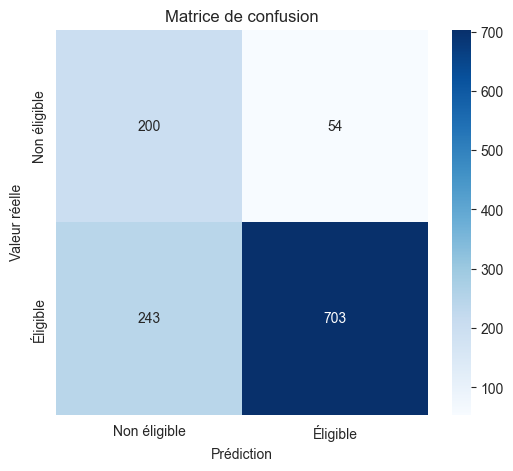

In [16]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non éligible", "Éligible"],
    yticklabels=["Non éligible", "Éligible"]
)

plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.show()


# Choix du seuil de décision
Par défaut, la classification utilise un seuil de 0,5. Pour une application réelle, ce seuil devra être choisi avec le métier.

In [17]:
def predict_with_threshold(model, data, threshold=0.5):
    """
    Retourne une prédiction oui/non à partir d'un seuil configurable.
    """
    probabilities = model.predict_proba(data)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    result = data.copy()
    result["eligibility_probability"] = probabilities.round(4)
    result["express_eligible"] = predictions
    result["decision"] = np.where(
        predictions == 1,
        "oui",
        "non"
    )

    return result


predictions_test = predict_with_threshold(
    model_pipeline,
    X_test,
    threshold=0.5
)

predictions_test.head()


,hour,day_of_week,weekend,distance_km,order_value_eur,weight_kg,stock_available,preparation_time_min,carrier_capacity,weather,delivery_zone,customer_type,eligibility_probability,express_eligible,decision
1784,10,5,1,7.54,201.08,6.89,1,26.1,0.26,orage,proche_banlieue,premium,0.5206,1,oui
3537,15,6,1,13.31,200.61,15.12,1,17.9,0.44,normal,banlieue,standard,0.3037,0,non
3426,21,6,1,1.73,45.75,17.78,1,21.6,0.31,neige,centre,standard,0.7365,1,oui
1242,14,0,0,4.27,159.41,0.48,0,13.1,0.76,normal,proche_banlieue,standard,0.6477,1,oui
1755,12,3,0,19.04,49.34,18.85,1,20.0,0.83,normal,proche_banlieue,standard,0.3113,0,non


# Fonction de prédiction métier
Cette fonction correspondra ensuite au cœur d’une API FastAPI.

In [18]:
def predict_order_eligibility(order_data, model, threshold=0.5):
    """
    Effectue une prédiction pour une commande.

    Parameters
    ----------
    order_data : dict
        Données d'une commande.
    model : Pipeline
        Pipeline scikit-learn entraînée.
    threshold : float
        Seuil à partir duquel la commande est considérée comme éligible.

    Returns
    -------
    dict
        Résultat de la prédiction.
    """
    missing_features = set(FEATURE_COLUMNS) - set(order_data.keys())

    if missing_features:
        raise ValueError(
            f"Variables manquantes : {sorted(missing_features)}"
        )

    input_df = pd.DataFrame(
        [{feature: order_data[feature] for feature in FEATURE_COLUMNS}]
    )

    probability = float(model.predict_proba(input_df)[0, 1])
    eligible = probability >= threshold

    return {
        "express_eligible": bool(eligible),
        "decision": "oui" if eligible else "non",
        "probability": round(probability, 4),
        "model_version": MODEL_VERSION,
        "prediction_timestamp": datetime.utcnow().isoformat()
    }


# Exemple de prédiction

In [19]:
example_order = {
    "hour": 14,
    "day_of_week": 2,
    "weekend": 0,
    "distance_km": 3.5,
    "order_value_eur": 89.90,
    "weight_kg": 2.4,
    "stock_available": 1,
    "preparation_time_min": 18,
    "carrier_capacity": 0.85,
    "weather": "normal",
    "delivery_zone": "centre",
    "customer_type": "premium",
}

prediction = predict_order_eligibility(
    example_order,
    model_pipeline,
    threshold=0.5
)

prediction


{'express_eligible': True,
 'decision': 'oui',
 'probability': 0.9366,
 'model_version': '1.0.0',
 'prediction_timestamp': '2026-10-06T12:01:27.081218'}

In [20]:
example_order_2 = {
    "hour": 21,
    "day_of_week": 6,
    "weekend": 1,
    "distance_km": 28,
    "order_value_eur": 25.00,
    "weight_kg": 18,
    "stock_available": 0,
    "preparation_time_min": 70,
    "carrier_capacity": 0.25,
    "weather": "orage",
    "delivery_zone": "rurale",
    "customer_type": "standard",
}

prediction_2 = predict_order_eligibility(
    example_order_2,
    model_pipeline,
    threshold=0.5
)

prediction_2


{'express_eligible': False,
 'decision': 'non',
 'probability': 0.0007,
 'model_version': '1.0.0',
 'prediction_timestamp': '2026-10-06T12:01:27.806644'}

# Tests fonctionnels de la prédiction

In [21]:
def run_prediction_tests(model):
    valid_order = {
        "hour": 10,
        "day_of_week": 1,
        "weekend": 0,
        "distance_km": 2,
        "order_value_eur": 50,
        "weight_kg": 1,
        "stock_available": 1,
        "preparation_time_min": 10,
        "carrier_capacity": 0.9,
        "weather": "normal",
        "delivery_zone": "centre",
        "customer_type": "premium",
    }

    result = predict_order_eligibility(valid_order, model)

    assert result["decision"] in {"oui", "non"}
    assert isinstance(result["express_eligible"], bool)
    assert 0 <= result["probability"] <= 1
    assert "model_version" in result

    invalid_order = valid_order.copy()
    del invalid_order["distance_km"]

    try:
        predict_order_eligibility(invalid_order, model)
        raise AssertionError(
            "Une variable obligatoire absente aurait dû provoquer une erreur."
        )
    except ValueError:
        pass

    print("Tous les tests de prédiction sont passés.")


run_prediction_tests(model_pipeline)


Tous les tests de prédiction sont passés.


# Sauvegarde du modèle

In [22]:
MODEL_PATH = ARTIFACTS_DIR / "express_delivery_model.joblib"
METRICS_PATH = ARTIFACTS_DIR / "metrics.json"
FEATURES_PATH = ARTIFACTS_DIR / "features.json"

joblib.dump(model_pipeline, MODEL_PATH)

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

with open(FEATURES_PATH, "w", encoding="utf-8") as file:
    json.dump(
        {
            "model_version": MODEL_VERSION,
            "target": TARGET_COLUMN,
            "features": FEATURE_COLUMNS,
            "numeric_features": NUMERIC_FEATURES,
            "categorical_features": CATEGORICAL_FEATURES,
        },
        file,
        indent=2
    )

print(f"Modèle sauvegardé dans : {MODEL_PATH}")
print(f"Métriques sauvegardées dans : {METRICS_PATH}")
print(f"Configuration sauvegardée dans : {FEATURES_PATH}")


Modèle sauvegardé dans : artifacts/express_delivery_model.joblib
Métriques sauvegardées dans : artifacts/metrics.json
Configuration sauvegardée dans : artifacts/features.json


# Rechargement du modèle sauvegardé
Cette étape simule le comportement d’un service de production qui charge un modèle déjà entraîné.

In [23]:
loaded_model = joblib.load(MODEL_PATH)

loaded_prediction = predict_order_eligibility(
    example_order,
    loaded_model
)

loaded_prediction


{'express_eligible': True,
 'decision': 'oui',
 'probability': 0.9366,
 'model_version': '1.0.0',
 'prediction_timestamp': '2026-10-06T12:01:32.519167'}

In [24]:
run_prediction_tests(loaded_model)

Tous les tests de prédiction sont passés.


# Simulation d’une pipeline batch
La pipeline batch traite ici un ensemble de nouvelles commandes. Dans une architecture cloud, cette fonction pourrait être exécutée selon une planification quotidienne ou horaire.

In [25]:
def batch_predict_orders(input_df, model, threshold=0.5):
    """
    Réalise une prédiction batch sur plusieurs commandes.
    """
    missing_features = set(FEATURE_COLUMNS) - set(input_df.columns)

    if missing_features:
        raise ValueError(
            f"Variables manquantes dans le batch : {sorted(missing_features)}"
        )

    result = input_df.copy()
    result["eligibility_probability"] = model.predict_proba(
        input_df[FEATURE_COLUMNS]
    )[:, 1]

    result["express_eligible"] = (
        result["eligibility_probability"] >= threshold
    ).astype(int)

    result["decision"] = np.where(
        result["express_eligible"] == 1,
        "oui",
        "non"
    )

    return result


batch_input = orders_clean.sample(
    n=10,
    random_state=RANDOM_STATE
)[FEATURE_COLUMNS]

batch_predictions = batch_predict_orders(
    batch_input,
    loaded_model
)

batch_predictions


,hour,day_of_week,weekend,distance_km,order_value_eur,weight_kg,stock_available,preparation_time_min,carrier_capacity,weather,delivery_zone,customer_type,eligibility_probability,express_eligible,decision
1782,22,5,1,15.44,242.71,6.63,0,26.6,0.81,normal,centre,standard,0.091398,0,non
3917,7,1,0,2.56,21.00,15.50,1,51.9,0.90,normal,centre,standard,0.839044,1,oui
221,18,1,0,2.82,93.85,10.39,0,29.3,0.85,pluie,rurale,standard,0.422299,0,non
2135,15,5,1,4.74,60.87,17.82,1,52.3,0.48,orage,proche_banlieue,standard,0.434863,0,non
5224,14,4,0,9.00,162.93,16.10,1,18.8,0.99,pluie,centre,standard,0.748509,1,oui
1168,21,2,0,1.52,232.58,7.50,1,23.4,0.53,normal,banlieue,standard,0.848319,1,oui
879,8,6,1,5.71,43.85,21.63,0,18.1,0.53,normal,proche_banlieue,standard,0.291574,0,non
156,15,4,0,1.84,32.95,16.12,1,32.3,0.29,normal,centre,standard,0.805330,1,oui
1657,20,4,0,3.16,140.03,4.23,1,24.2,0.74,pluie,centre,premium,0.879914,1,oui
323,22,0,0,23.63,37.92,10.66,1,8.1,0.94,normal,centre,standard,0.289499,0,non


# Simulation d’un flux temps réel
Cette cellule simule la réception de commandes une par une. Elle pourra ensuite être remplacée par une file de messages ou un endpoint API.

In [26]:
incoming_orders = [
    example_order,
    example_order_2,
    {
        "hour": 12,
        "day_of_week": 3,
        "weekend": 0,
        "distance_km": 6,
        "order_value_eur": 120,
        "weight_kg": 3,
        "stock_available": 1,
        "preparation_time_min": 20,
        "carrier_capacity": 0.70,
        "weather": "pluie",
        "delivery_zone": "proche_banlieue",
        "customer_type": "standard",
    },
]

for index, incoming_order in enumerate(incoming_orders, start=1):
    result = predict_order_eligibility(
        incoming_order,
        loaded_model
    )

    print(f"Commande entrante n°{index}")
    print(result)
    print()


Commande entrante n°1
{'express_eligible': True, 'decision': 'oui', 'probability': 0.9366, 'model_version': '1.0.0', 'prediction_timestamp': '2026-10-06T12:01:36.341151'}

Commande entrante n°2
{'express_eligible': False, 'decision': 'non', 'probability': 0.0007, 'model_version': '1.0.0', 'prediction_timestamp': '2026-10-06T12:01:36.350942'}

Commande entrante n°3
{'express_eligible': True, 'decision': 'oui', 'probability': 0.8135, 'model_version': '1.0.0', 'prediction_timestamp': '2026-10-06T12:01:36.360538'}



# Génération d’un fichier de prédictions

In [27]:
PREDICTIONS_PATH = ARTIFACTS_DIR / "batch_predictions.csv"

batch_predictions.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print(f"Résultats batch sauvegardés dans : {PREDICTIONS_PATH}")


Résultats batch sauvegardés dans : artifacts/batch_predictions.csv


# Importance indicative des variables
Avec une régression logistique, les coefficients donnent une indication sur l’influence des variables après transformation.

In [28]:
trained_preprocessor = loaded_model.named_steps["preprocessor"]
trained_classifier = loaded_model.named_steps["classifier"]

feature_names = trained_preprocessor.get_feature_names_out()
coefficients = trained_classifier.coef_[0]

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    })
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
)

feature_importance.head(15)


,feature,coefficient,absolute_coefficient
3,numeric__distance_km,-0.993968,0.993968
6,numeric__stock_available,0.608628,0.608628
8,numeric__carrier_capacity,0.297967,0.297967
7,numeric__preparation_time_min,-0.285643,0.285643
14,categorical__delivery_zone_centre,0.260542,0.260542
5,numeric__weight_kg,-0.194577,0.194577
10,categorical__weather_normal,0.194405,0.194405
2,numeric__weekend,-0.187876,0.187876
16,categorical__delivery_zone_rurale,-0.177477,0.177477
17,categorical__customer_type_premium,0.110507,0.110507


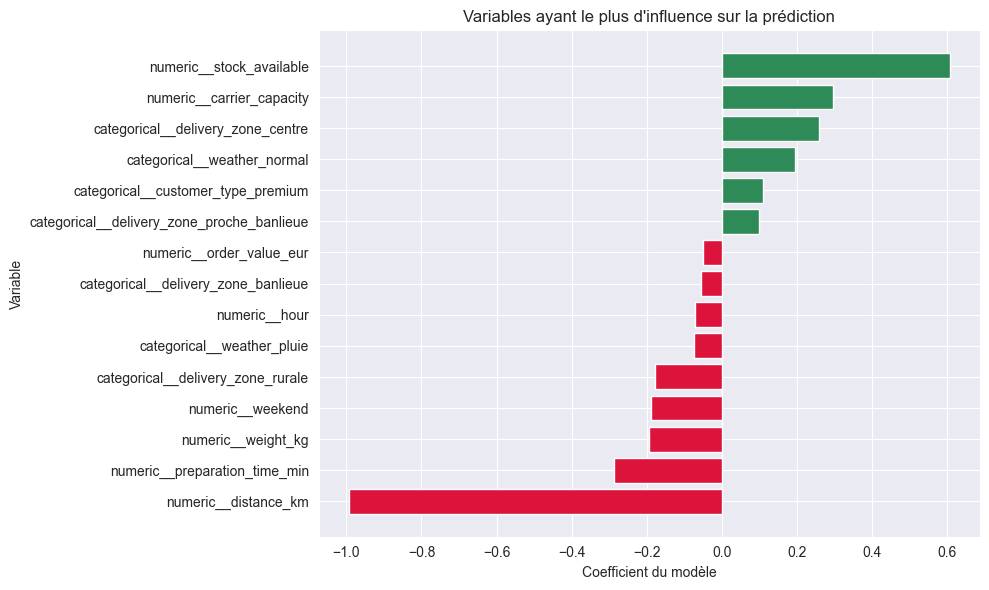

In [29]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values(
    "coefficient"
)

colors = [
    "crimson" if value < 0 else "seagreen"
    for value in top_features["coefficient"]
]

plt.barh(
    top_features["feature"],
    top_features["coefficient"],
    color=colors
)

plt.title("Variables ayant le plus d'influence sur la prédiction")
plt.xlabel("Coefficient du modèle")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


# Résumé du modèle

In [30]:
model_card = {
    "project": PROJECT_NAME,
    "model_version": MODEL_VERSION,
    "model_type": "Régression logistique",
    "task": "Classification binaire",
    "target": TARGET_COLUMN,
    "positive_class": "Commande éligible à la livraison express",
    "negative_class": "Commande non éligible à la livraison express",
    "features": FEATURE_COLUMNS,
    "threshold": 0.5,
    "training_rows": len(X_train),
    "test_rows": len(X_test),
    "metrics": metrics,
    "limitations": [
        "Le jeu de données utilisé est synthétique.",
        "La décision ne doit pas être utilisée sans validation des règles métier.",
        "Les performances peuvent varier sur des données réelles.",
        "Le modèle ne remplace pas une analyse des contraintes opérationnelles.",
    ],
}

print(json.dumps(model_card, indent=2, ensure_ascii=False))


{
  "project": "eligibilite-livraison-express",
  "model_version": "1.0.0",
  "model_type": "Régression logistique",
  "task": "Classification binaire",
  "target": "express_eligible",
  "positive_class": "Commande éligible à la livraison express",
  "negative_class": "Commande non éligible à la livraison express",
  "features": [
    "hour",
    "day_of_week",
    "weekend",
    "distance_km",
    "order_value_eur",
    "weight_kg",
    "stock_available",
    "preparation_time_min",
    "carrier_capacity",
    "weather",
    "delivery_zone",
    "customer_type"
  ],
  "threshold": 0.5,
  "training_rows": 4800,
  "test_rows": 1200,
  "metrics": {
    "accuracy": 0.7525,
    "precision": 0.9286657859973579,
    "recall": 0.7431289640591966,
    "f1_score": 0.8256018790369936,
    "roc_auc": 0.8479424347855038
  },
  "limitations": [
    "Le jeu de données utilisé est synthétique.",
    "La décision ne doit pas être utilisée sans validation des règles métier.",
    "Les performances peuv

# Arrêt propre de l’expérience MLflow

In [31]:
print(
    "Pour consulter les expériences MLflow en local, exécuter dans un terminal :"
)
print("mlflow ui")


Pour consulter les expériences MLflow en local, exécuter dans un terminal :
mlflow ui


## Résultat attendu à la fin du notebook
Le notebook produit notamment les fichiers suivants :
```text
artifacts/
├── express_delivery_model.joblib
├── features.json
├── metrics.json
└── batch_predictions.csv
```

Le fichier `express_delivery_model.joblib` pourra être chargé par une application Python ou une API FastAPI.

Exemple de chargement dans une future application :


In [32]:
import joblib

model = joblib.load(
    "artifacts/express_delivery_model.joblib"
)


Exemple de prédiction depuis cette application :

In [33]:
prediction = model.predict_proba(
    input_dataframe
)[:, 1]

decision = "oui" if prediction[0] >= 0.5 else "non"


NameError: name 'input_dataframe' is not defined

# Éléments à industrialiser
| Élements à industrialiser                | Séance | Solution technique |
|------------------------------------------|--------|--------------------|
| Collecte de données                      | 1      | ?                  |
| Exposition d'une fonction de prédiction  | 1      | ?                  |
| Entraînement du modèle                   | 1      | ?                  |
| Prédiction à l'aide du modèle            | 1      | ?                  |
| Environnement (dev -> test -> prod)      | 1 & 3  | ?                  |
| Déploiement                              | 2      | ?                  |
| Sécurisation de la chaîne de déploiement | 2      | ?                  |
| Sauvegarde du modèle                     | 3      | ?                  |
| CI/CD                                    | 3      | ?                  |
| Nettoyage des données                    | 4      | ?                  |
| Validation des données                   | 4      | ?                  |
| MLFlow                                   | 4      | ?                  |
| Pipeline Batch                           | 5      | ?                  |
| Flux temps réel                          | 5      | ?                  |
| Supervision                              | 6      | ?                  |
| Mise à l'échelle (pour les plus rapides) | 6      | ?                  |